<a href="https://colab.research.google.com/github/Data-Vitor/fiap-data-science/blob/main/nemec-estatistica/cap03_medicoes_distrubuicoes_estatisticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Hello world')


Hello world


In [8]:
'''#média python, pandas
import pandas as pd

media = df['notas'].mean()
print(media)

#Média ponderada

media_ponderada = (df['notas']*df['pesos']).sum() / df['pesos'].sumo()
print(media_ponderada)


#mediana

mediana = df['notas'].median()
print(mediana)

#utilizando numpy

import numpy as np

notas = [3.5, 5.0, 6.0, 6.5, 7.0, 7.5, 8.0, 9.0]
mediana = np.median(notas)
print(mediana)

#moda (a mais fácil de todas)

moda = df['notas'].mode()
print(moda)


#média aparada (cortas os outliers e faz a média do que resta)

from scipy.stats import trim_mean

media_aparada = trim_mean(df['notas'], 0.1)
print(media_aparada)'''


#percentil

import numpy as np
import pandas as pd
imc = [18.5, 20.3, 21.7, 22.8, 24.2, 26.1, 28.7, 30.5, 32.8, 35.4, 37.0]

#usando numpy
p25 = np.percentile(imc,25)
p78 = np.percentile(imc, 78)

#usando pandas

df = pd.DataFrame({'IMC': imc })
p25_pandas = df['IMC'].quantile(0.25)
p78_pandas = df['IMC'].quantile(0.78)

print(p25)
print(p78_pandas)

22.25
32.339999999999996


Calculando Desvio Padrão


In [2]:
import pandas as pd
import numpy as np

notas = [77,77,81,81,83,84,93,94,95]

df = pd.DataFrame({'notas':notas})

#Desvio padrão populacional (divide por n)

dp_pop_numpy = np.std(notas, ddof = 0)
dp_pop_pandas = df['notas'].std(ddof = 0)

# Desvio padrão amostral (divide por n-1)
dp_amo_numpy = np.std(notas, ddof=1)
dp_amo_pandas = df['notas'].std(ddof = 1 )

print(dp_pop_numpy)
print(dp_pop_pandas)
print(dp_amo_numpy)
print(dp_amo_pandas)



6.749485577105529
6.749485577105529
7.158910531638177
7.158910531638177


Calculando o desvio padrão:

In [4]:
import numpy as np

import pandas as pd

notas = [7.0, 8.5, 9.0, 8.0, 7.5]

bonus = [1, 2, 0, 1, 2]
notas_finais = [a + b for a, b in zip(notas, bonus)]

# Variancia amostral (n-1)

print("Variancia (notas):",np.var(bonus, ddof=1))

print("Variancta (bonus):", np.var(bonus, ddof=1))

print("Variancia (nota final):", np.var(notas_finais, ddof=1))

# Usando Pandas

df = pd. DataFrame({'notas': notas, 'bonus': bonus, 'final': notas_finais})

print("Variancta (Pandas nota final):", df['final'].var())

Variancia (notas): 0.7000000000000001
Variancta (bonus): 0.7000000000000001
Variancia (nota final): 0.825
Variancta (Pandas nota final): 0.825


calculando a amplitude:


In [5]:
# Usando lista comum

notas = [77, 77, 81, 81, 83, 84, 93, 93, 94, 95]
amplitude = max(notas) - min(notas)
print("Amplitude (lista):", amplitude)

# Usando pandas

import pandas as pd

df = pd.DataFrame({'notas': notas})
amplitude_pandas = df['notas'].max() - df['notas'].min()
print("Amplitude (Pandas):", amplitude_pandas)

Amplitude (lista): 18
Amplitude (Pandas): 18


Desvio Absoluto Médio:


In [6]:
import numpy as np

notas = [77,77,81,83,84,93,94,95]
media = np.mean(notas)
dam = np.mean([abs(x-media)for x in notas])
print('Desvio absoluto médio:',round(dam,2))

Desvio absoluto médio: 6.38


Desvio Absoluto mediano da mediana

In [8]:
import numpy as np
import pandas as po
notas = [77, 77, 81, 81, 83, 84, 93, 93, 94, 95]
mediana = np.median(notas)
mad = np.median([abs(x - mediana) for x in notas])
print("Desvio absoluto mediano da mediana (MAD):",mad )

# Ou usando pandas diretamente
df = pd.DataFrame({f'notas': notas})
mad_pandas = (df['notas'] - df['notas'].median()).abs().median()
print("MAD (Pandas):", mad_pandas)

Desvio absoluto mediano da mediana (MAD): 6.5
MAD (Pandas): 6.5


Distribuições Estatisticas:

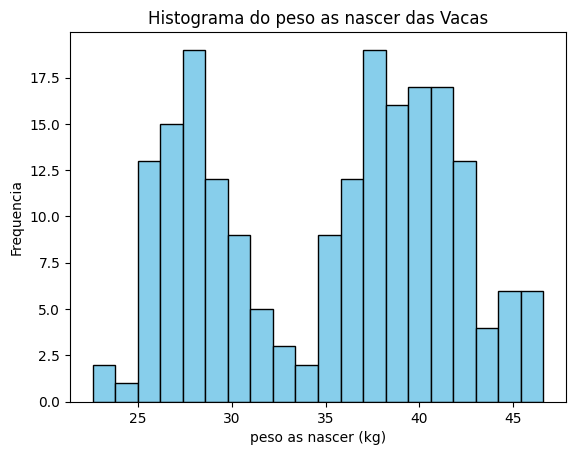

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/datasets/vacas.csv')

#plota o histograma

plt.hist(df['peso_nasc'], bins = 20, color ='skyblue', edgecolor='black')
plt.title('Histograma do peso as nascer das Vacas')
plt.xlabel('peso as nascer (kg)')
plt.ylabel('Frequencia')
plt.show()

Densidadade e probabilidade : Calculando o Z-score

In [6]:
from scipy.stats import norm

prob = norm.cdf(-1.25) - norm.cdf(-2.5)
print(prob*100)

9.944010834107923


Determinando um corte para a produção de leite alta e baixa.

In [8]:
#primeiro iremos transformar o 5% em um z-score
from scipy.stats import norm

z5 = norm.ppf(0.95)
corte_baixo = 25 + z5*4
print(f'Corte para os 5% de maior produção: {corte_baixo:.2f} litros')


#MANEIRISSIMO.

Corte para os 5% de maior produção: 31.58 litros


Densidade de probabilidade em python:

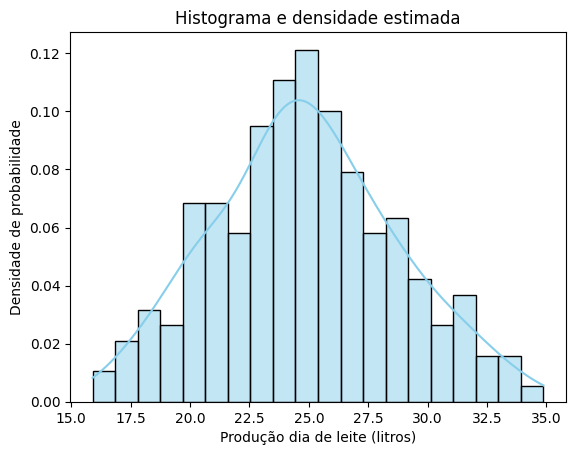

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#exemplo: Gerando dados normais simulados
dados = np.random.normal(loc=25, scale=4, size=200)

#plotando o histograma + densidade

sns.histplot(dados, kde=True, stat="density", bins=20, color='Skyblue', edgecolor='black')
plt.xlabel('Produção dia de leite (litros)')
plt.ylabel('Densidade de probabilidade')
plt.title('Histograma e densidade estimada')
plt.show()

Estimando probabilidades a partir da distribuição binomial.

In [14]:
#Calculando a probabilidade de uma vaca ter exatamente 4 partos bem sucedidos (em 5 tentativas p = 0.8)

from scipy.stats import binom

prob = binom.pmf(4, n=5, p=0.8)+-
print(f'Probabilidade de 4 partos bem-sucedidos:{prob:.1%}')

Probabilidade de 4 partos bem-sucedidos:41.0%


Calculando probabilidade com a distribuição de Poisson

In [1]:
from scipy.stats import poisson


lambda_ = 3
#probabiliadade acumulada de ate 3 ligacoes
prob_3 = poisson.cdf(3, mu=lambda_)
prob_acima3 = 1 - prob_3
print(f'Probabilidade de mais de 3 ligações em 1 minuto: {prob_acima3:1%}')

Probabilidade de mais de 3 ligações em 1 minuto: 35.276811%


Calculando probabilidades com a distribuição exponencial

In [4]:
from scipy.stats import expon

lambda_ = 1/20 #1 ligação a cada 20 segundos

prob_10s = expon.cdf(10, scale=1/lambda_)
print(f'Probabilidade de recerber em até 10s: {prob_10s:.1%}')

#2 Quantos segundos esperar para 80% de chance?
t_80 = expon.ppf(0.8, scale=1/lambda_)
print(f'tempo para 80% de chance: {t_80:.1f} segundos')

Probabilidade de recerber em até 10s: 39.3%
tempo para 80% de chance: 32.2 segundos


Assimetria:

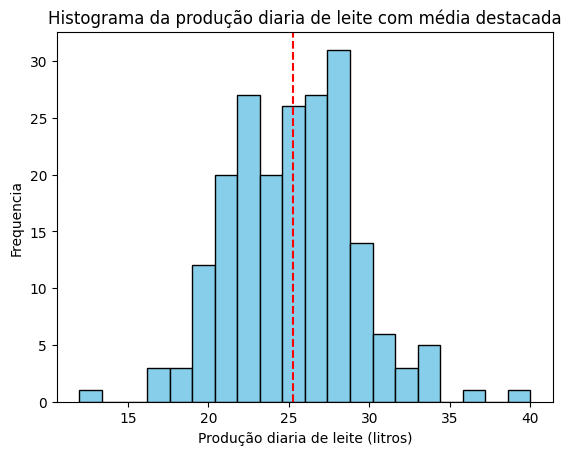

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/datasets/vacas.csv')

#descobrindo a média:

media = df['leite_dia'].mean()

#plota o histograma

plt.hist(df['leite_dia'], bins = 20, color ='skyblue', edgecolor='black')
plt.title('Histograma da produção diaria de leite com média destacada')
plt.axvline(x=media, color='red', linestyle='--')
plt.xlabel('Produção diaria de leite (litros)')
plt.ylabel('Frequencia')
plt.show()

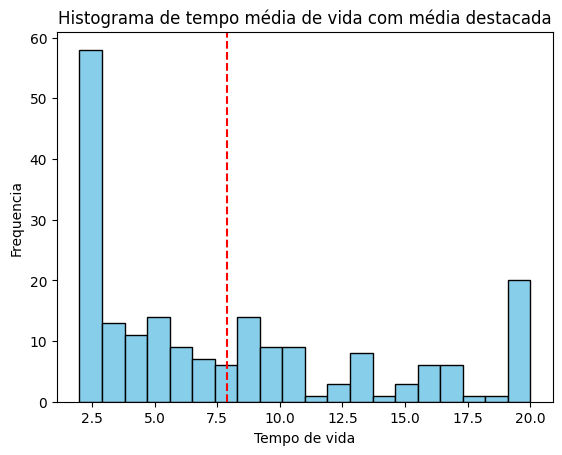

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/datasets/vacas.csv')

#descobrindo a média:

media = df['tempo_vida'].mean()

#plota o histograma

plt.hist(df['tempo_vida'], bins = 20, color ='skyblue', edgecolor='black')
plt.title('Histograma de tempo média de vida com média destacada')
plt.axvline(x=media, color='red', linestyle='--')
plt.xlabel('Tempo de vida')
plt.ylabel('Frequencia')
plt.show()

Calculando assimetria em python:

In [19]:
import pandas as pd
from scipy.stats import skew

#ler o data set
df = pd.read_csv('/content/drive/MyDrive/datasets/vacas.csv')

#calcula a skewness
assimetria_leite = skew(df['leite_dia'])
assimetria_tempovida = skew(df['tempo_vida'])

print('Assimetria leite_dia:', round(assimetria_leite, 2))
print('Assimetria tempo_vida', round(assimetria_tempovida, 2))

Assimetria leite_dia: 0.23
Assimetria tempo_vida 0.8


calculando a curtose em python:

In [22]:
import pandas as pd
from scipy.stats import kurtosis

df = pd.read_csv('/content/drive/MyDrive/datasets/vacas.csv')

curtose_leite = kurtosis(df['leite_dia'], fisher=True)
curtose_tempovida = kurtosis(df['tempo_vida'], fisher = True)

print('Curtose leite_dia: ', round(curtose_leite,2))
print('curtose tempo_vida', round(curtose_tempovida,2))



Curtose leite_dia:  0.88
curtose tempo_vida -0.62


Calculando o intervalo de confiança clássico para a média e a proporção, assumindo a normalidade - Bootstrap.

In [32]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

#dados de exemplo: produção de leite (litros/dia)
dados = np.array([25,28,24,30,27,22,29,26,31,23])
conf = 0.95
n =len(dados)

#IC da média (usando distribuição t de Student)

media= np.mean(dados)
sem =stats.sem(dados) #erro padrão da média
ic_media = stats.t.interval(conf, df=n-1, loc=media, scale =sem)
print(f'IC 95% da média: [{ic_media[0]:.2f}, {ic_media[1]:.2f}]')

#ic da médioa da proporção (exemplo: proporção de vacas com produção > 28 litros)
#número de vacas acima de 28 litros

sucessos = np.sum(dados>28)
ic_prop = proportion_confint(sucessos, n, alpha=1-conf, method='normal')
print(f"IC 95% da proporção (normal): [{ic_prop[0]:.2f}, {ic_prop[1]:.2f}]")

IC 95% da média: [24.33, 28.67]
IC 95% da proporção (normal): [0.02, 0.58]
